### Data Understanding & Cleaning

#### 1.1 Import Pandas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pandas → dataset handling

numpy → numerical operations

matplotlib → we'll use it later for EDA

### 1.2 Load the Dataset

In [7]:
df = pd.read_csv("reviews.csv")

open data file 

In [8]:
df.head()

,review_id,review_text,sentiment,category,source
0,1,This product exceeded my expectations in sever...,Positive,Books,Online Store
1,2,The item is uncomfortable to use and poorly de...,Negative,Books,Online Store
2,3,The product comes with a charging adapter and ...,Neutral,Travel,Customer Survey
3,4,Customer support was slow and did not solve my...,Negative,Home & Kitchen,Website
4,5,"The design is simple, attractive, and comforta...",Positive,Sports,Online Store


display first 5 lines of data

### 1.3 Check Dataset Size

In [9]:
df.shape

(10000, 5)

#### 1.4 Check Column Names

In [10]:
df.columns


Index(['review_id', 'review_text', 'sentiment', 'category', 'source'], dtype='str')

#### 1.5 Understand the Dataset

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    10000 non-null  int64
 1   review_text  10000 non-null  str  
 2   sentiment    10000 non-null  str  
 3   category     10000 non-null  str  
 4   source       10000 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.5 MB


#### 1.6 Check Missing Values

In [12]:
df.isnull().sum()

review_id      0
review_text    0
sentiment      0
category       0
source         0
dtype: int64

#### 1.7 Check Duplicate Rows


In [13]:
df.duplicated().sum()


np.int64(0)

#### 1.8 Check Sentiment Classes

In [14]:
df["sentiment"].value_counts()

sentiment
Positive    3334
Negative    3333
Neutral     3333
Name: count, dtype: int64

In [15]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
Positive    33.34
Negative    33.33
Neutral     33.33
Name: proportion, dtype: float64

#### 1.9 Look at Actual Reviews

In [16]:
df[["review_text", "sentiment"]].head(10)

,review_text,sentiment
0,This product exceeded my expectations in sever...,Positive
1,The item is uncomfortable to use and poorly de...,Negative
2,The product comes with a charging adapter and ...,Neutral
3,Customer support was slow and did not solve my...,Negative
4,"The design is simple, attractive, and comforta...",Positive
5,The delivery was late and the package arrived ...,Negative
6,This is one of the better purchases I have mad...,Positive
7,The product works perfectly and feels well mad...,Positive
8,Customer support responded quickly and solved ...,Positive
9,"The service was friendly, efficient, and profe...",Positive


In [17]:
df[["review_text", "sentiment"]].head(10)

,review_text,sentiment
0,This product exceeded my expectations in sever...,Positive
1,The item is uncomfortable to use and poorly de...,Negative
2,The product comes with a charging adapter and ...,Neutral
3,Customer support was slow and did not solve my...,Negative
4,"The design is simple, attractive, and comforta...",Positive
5,The delivery was late and the package arrived ...,Negative
6,This is one of the better purchases I have mad...,Positive
7,The product works perfectly and feels well mad...,Positive
8,Customer support responded quickly and solved ...,Positive
9,"The service was friendly, efficient, and profe...",Positive


In [18]:
df["review_text"].sample(10, random_state=42)

6252    The review is based on my first week of use. T...
4684    The service was friendly, efficient, and profe...
1731    The store offers standard and express delivery...
4742    The product is available in three different si...
4521    The instructions were confusing and the setup ...
6340    I expected much better quality for the price. ...
576     The product does not match the description pro...
5202    Customer support responded quickly and solved ...
6363    Customer support was slow and did not solve my...
439     The packaging was poor and some parts were mis...
Name: review_text, dtype: str

The dataset contains 10,000 reviews and 5 columns. There are no missing values or duplicate rows. The target variable contains three sentiment classes: Positive, Negative, and Neutral with an almost perfectly balanced distribution.

Rows:              10,000

Columns:           5

Missing values:    None

Duplicate rows:    None

Target:            sentiment

Classes:           Positive, Negative, Neutral

Class distribution: Almost perfectly balanced

Text quality:      Clean, readable customer-review sentences

### STEP 2 — Exploratory Data Analysis

2.1 Create a sentiment count table

In [19]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
Positive    3334
Negative    3333
Neutral     3333
Name: count, dtype: int64

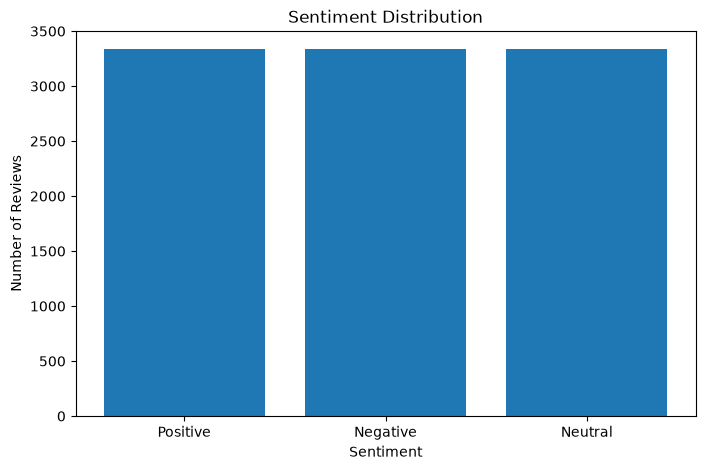

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution")

plt.show()

2.2 Review length

In [21]:
df["review_length"] = df["review_text"].str.len()

In [22]:
df[["review_text", "review_length"]].head()


,review_text,review_length
0,This product exceeded my expectations in sever...,92
1,The item is uncomfortable to use and poorly de...,79
2,The product comes with a charging adapter and ...,60
3,Customer support was slow and did not solve my...,102
4,"The design is simple, attractive, and comforta...",95


In [23]:
df["review_length"].describe()

count    10000.000000
mean        94.639100
std         21.700068
min         43.000000
25%         84.000000
50%         99.000000
75%        109.000000
max        136.000000
Name: review_length, dtype: float64

2.3 Review length distribution

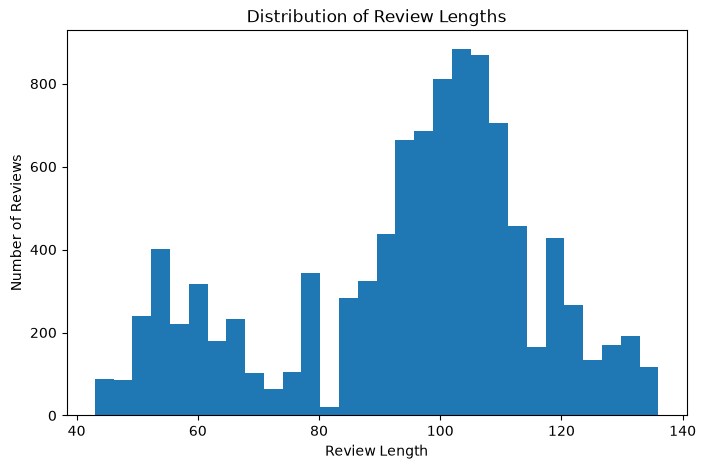

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df["review_length"], bins=30)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

2.4 Categories

In [25]:
df["category"].value_counts()

category
Travel            1305
Clothing          1288
Sports            1278
Beauty            1272
Home & Kitchen    1245
Electronics       1239
Food & Grocery    1205
Books             1168
Name: count, dtype: int64

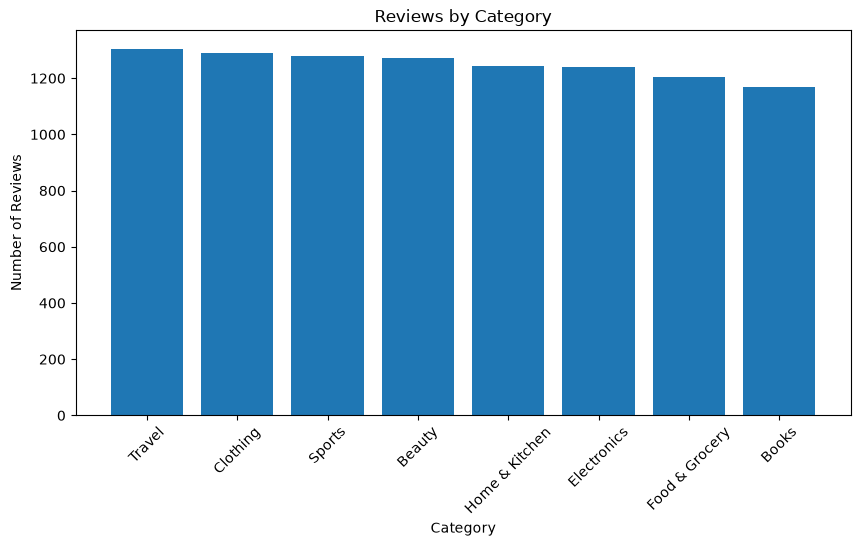

In [26]:
plt.figure(figsize=(10, 5))

category_counts = df["category"].value_counts()

plt.bar(category_counts.index, category_counts.values)

plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.title("Reviews by Category")

plt.xticks(rotation=45)

plt.show()

2.5 Category vs Sentiment

In [27]:
category_sentiment = pd.crosstab(
    df["category"],
    df["sentiment"]
)

category_sentiment

sentiment,Negative,Neutral,Positive
category,,,
Beauty,432,450,390
Books,398,370,400
Clothing,466,398,424
Electronics,407,419,413
Food & Grocery,369,431,405
Home & Kitchen,408,407,430
Sports,416,446,416
Travel,437,412,456


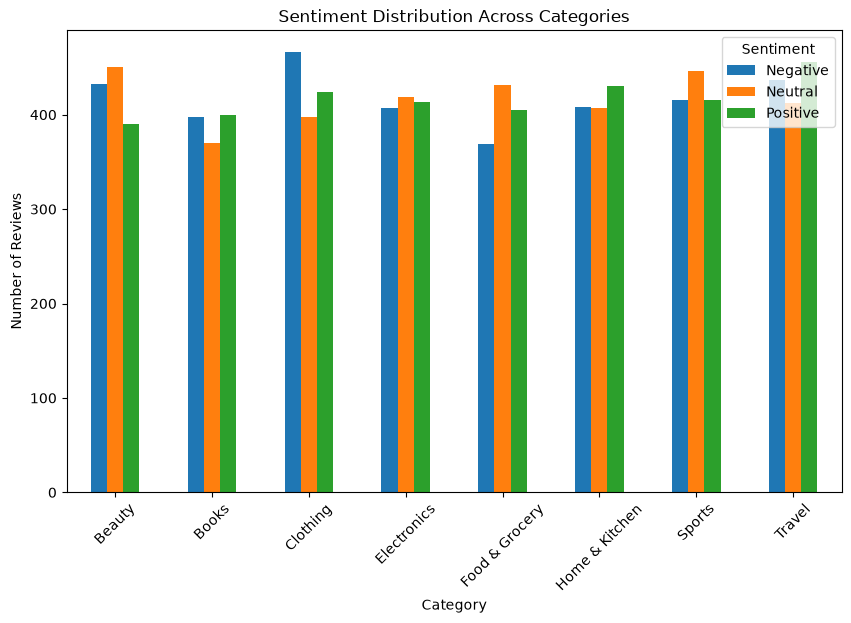

In [28]:
category_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution Across Categories")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")

plt.show()

2.6 Sentiment vs Review Length

In [29]:
df.groupby("sentiment")["review_length"].mean()

sentiment
Negative    90.522952
Neutral     97.224422
Positive    96.169466
Name: review_length, dtype: float64

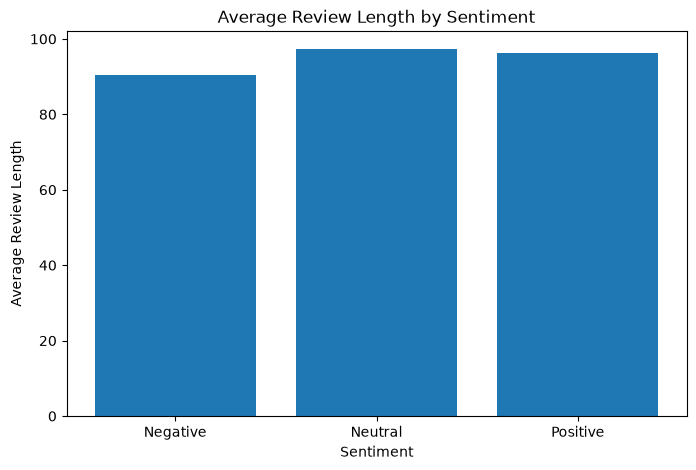

In [30]:
avg_length = df.groupby("sentiment")["review_length"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_length.index, avg_length.values)

plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")
plt.title("Average Review Length by Sentiment")

plt.show()

### STEP 3 — NLP Text Preprocessing

3.1 First: Look at raw text

In [31]:
df["review_text"]

0       This product exceeded my expectations in sever...
1       The item is uncomfortable to use and poorly de...
2       The product comes with a charging adapter and ...
3       Customer support was slow and did not solve my...
4       The design is simple, attractive, and comforta...
                              ...                        
9995    The battery drains quickly and does not last a...
9996    I have been using the product for about one we...
9997    The box included the accessories listed in the...
9998    I really like this product; it is useful, reli...
9999    The battery lasts a long time and charges quic...
Name: review_text, Length: 10000, dtype: str

3.2 Lowercase

In [32]:
df["cleaned_text"] = df["review_text"].str.lower()

In [33]:
df[["review_text", "cleaned_text"]].head()

,review_text,cleaned_text
0,This product exceeded my expectations in sever...,this product exceeded my expectations in sever...
1,The item is uncomfortable to use and poorly de...,the item is uncomfortable to use and poorly de...
2,The product comes with a charging adapter and ...,the product comes with a charging adapter and ...
3,Customer support was slow and did not solve my...,customer support was slow and did not solve my...
4,"The design is simple, attractive, and comforta...","the design is simple, attractive, and comforta..."


3.3 Remove unnecessary punctuation

In [34]:
import re

In [35]:
df["cleaned_text"] = df["cleaned_text"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x)
)

In [36]:
df[["review_text", "cleaned_text"]].head()

,review_text,cleaned_text
0,This product exceeded my expectations in sever...,this product exceeded my expectations in sever...
1,The item is uncomfortable to use and poorly de...,the item is uncomfortable to use and poorly de...
2,The product comes with a charging adapter and ...,the product comes with a charging adapter and ...
3,Customer support was slow and did not solve my...,customer support was slow and did not solve my...
4,"The design is simple, attractive, and comforta...",the design is simple attractive and comfortabl...


3.4 Normalize extra spaces


In [37]:
df["cleaned_text"] = df["cleaned_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [38]:
df[["review_text", "cleaned_text"]].head(10)

,review_text,cleaned_text
0,This product exceeded my expectations in sever...,this product exceeded my expectations in sever...
1,The item is uncomfortable to use and poorly de...,the item is uncomfortable to use and poorly de...
2,The product comes with a charging adapter and ...,the product comes with a charging adapter and ...
3,Customer support was slow and did not solve my...,customer support was slow and did not solve my...
4,"The design is simple, attractive, and comforta...",the design is simple attractive and comfortabl...
5,The delivery was late and the package arrived ...,the delivery was late and the package arrived ...
6,This is one of the better purchases I have mad...,this is one of the better purchases i have mad...
7,The product works perfectly and feels well mad...,the product works perfectly and feels well mad...
8,Customer support responded quickly and solved ...,customer support responded quickly and solved ...
9,"The service was friendly, efficient, and profe...",the service was friendly efficient and profess...


STEP 4 — TF-IDF

4.1 Import TF-IDF

#####  4. Feature Extraction - TF-IDF

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

4.2 Create the TF-IDF Vectorizer

In [40]:
tfidf = TfidfVectorizer()

4.3 Fit and Transform our reviews

In [41]:
X = tfidf.fit_transform(df["cleaned_text"])

4.4 Check the shape

In [42]:
X.shape

(10000, 266)

In [43]:
category_sentiment = pd.crosstab(
    df["category"],
    df["sentiment"]
)

category_sentiment

sentiment,Negative,Neutral,Positive
category,,,
Beauty,432,450,390
Books,398,370,400
Clothing,466,398,424
Electronics,407,419,413
Food & Grocery,369,431,405
Home & Kitchen,408,407,430
Sports,416,446,416
Travel,437,412,456


4.5 See the vocabulary

In [44]:
len(tfidf.vocabulary_)

266

In [45]:
list(tfidf.vocabulary_.keys())[:20]

['this',
 'product',
 'exceeded',
 'my',
 'expectations',
 'in',
 'several',
 'ways',
 'it',
 'has',
 'been',
 'good',
 'experience',
 'so',
 'far',
 'the',
 'item',
 'is',
 'uncomfortable',
 'to']

4.6 Look at one review's TF-IDF representation

In [46]:
df["cleaned_text"].iloc[0]

'this product exceeded my expectations in several ways it has been a good experience so far'

4.7 Understand it visually

In [47]:
X[0]


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 266)>

In [48]:
feature_names = tfidf.get_feature_names_out()

In [49]:
first_review = X[0].toarray().flatten()

In [50]:
tfidf_first_review = pd.DataFrame({
    "word": feature_names,
    "tfidf_value": first_review
})

In [51]:
tfidf_first_review = tfidf_first_review[
    tfidf_first_review["tfidf_value"] > 0
]

In [52]:
tfidf_first_review.sort_values(
    "tfidf_value",
    ascending=False
)

,word,tfidf_value
76,exceeded,0.380813
78,expectations,0.380813
254,ways,0.380813
197,several,0.327323
96,good,0.274172
104,in,0.248323
131,my,0.226660
82,far,0.216038
208,so,0.216038
20,been,0.215989


4.8 — Create the Target Variable

In [53]:
y = df["sentiment"]

In [54]:
y.head()

0    Positive
1    Negative
2     Neutral
3    Negative
4    Positive
Name: sentiment, dtype: str

In [55]:
y.shape

(10000,)

In [56]:
y.value_counts()

sentiment
Positive    3334
Negative    3333
Neutral     3333
Name: count, dtype: int64

4.9 — Train/Test Split

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
X_train.shape

(8000,)

In [60]:
X_test.shape

(2000,)

In [61]:
y_train.value_counts()

sentiment
Positive    2667
Neutral     2667
Negative    2666
Name: count, dtype: int64

In [62]:
y_test.value_counts()


sentiment
Negative    667
Positive    667
Neutral     666
Name: count, dtype: int64

4.10 — Proper TF-IDF Transformation

In [63]:
X = tfidf.fit_transform(df["cleaned_text"])

Step 1 — Create a fresh vectorizer

In [64]:
tfidf = TfidfVectorizer()

Step 2 — Fit ONLY on training data

In [65]:
X_train_tfidf = tfidf.fit_transform(X_train)

Step 3 — Transform test data

In [66]:
X_test_tfidf = tfidf.transform(X_test)

4.11 Check the shapes

In [67]:
X_train_tfidf.shape

(8000, 266)

In [68]:
X_test_tfidf.shape

(2000, 266)

STEP 5 — MODEL TRAINING

5.1 Import Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression

5.2 Create the model

In [70]:
model_lr = LogisticRegression(max_iter=1000)

5.3 Train it

In [71]:
model_lr.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

5.4 Make predictions

In [72]:
y_pred_lr = model_lr.predict(X_test_tfidf)

5.5 — Evaluate Logistic Regression

5.5.1 Import evaluation metrics

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

5.5.2 Accuracy

In [74]:
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 1.0


5.5.3 Precision

In [75]:
precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Precision:", precision)

Precision: 1.0


5.5.4 Recall

In [76]:
recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Recall:", recall)

Recall: 1.0


5.5.5 F1-score

In [77]:
f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 1.0


5.6 Classification Report

In [78]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       667
     Neutral       1.00      1.00      1.00       666
    Positive       1.00      1.00      1.00       667

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



5.7 — Confusion Matrix

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [80]:
cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[667,   0,   0],
       [  0, 666,   0],
       [  0,   0, 667]])

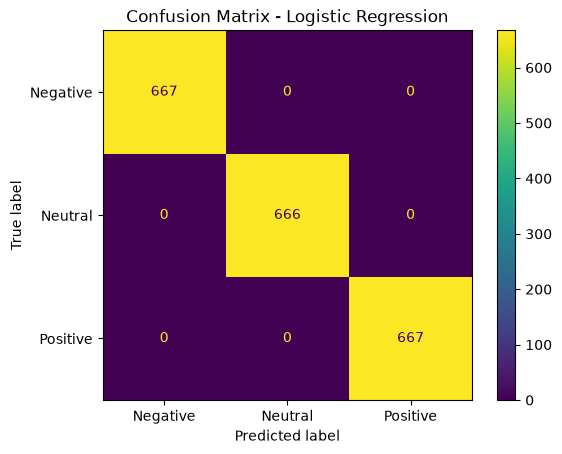

In [81]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_lr.classes_
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

5.8 — Check for duplicate reviews

In [82]:
df["cleaned_text"].duplicated().sum()

np.int64(9700)

In [83]:
df["cleaned_text"].nunique()
4

4

5.8.1 Let's verify the 4 unique reviews

In [84]:
df[["cleaned_text", "sentiment"]].drop_duplicates()

,cleaned_text,sentiment
0,this product exceeded my expectations in sever...,Positive
1,the item is uncomfortable to use and poorly de...,Negative
2,the product comes with a charging adapter and ...,Neutral
3,customer support was slow and did not solve my...,Negative
4,the design is simple attractive and comfortabl...,Positive
...,...,...
1489,the software is slow unstable and difficult to...,Negative
1569,i really like this product it is useful reliab...,Positive
1572,i have been using the product for about one we...,Neutral
1637,i really like this product it is useful reliab...,Positive


In [85]:
duplicate_sentiment_check = (
    df.groupby("cleaned_text")["sentiment"]
      .nunique()
)

duplicate_sentiment_check

cleaned_text
customer support responded quickly and solved my problem                                                                     1
customer support responded quickly and solved my problem i would consider buying it again                                    1
customer support responded quickly and solved my problem i would recommend it to someone looking for this type of product    1
customer support responded quickly and solved my problem it has been a good experience so far                                1
customer support responded quickly and solved my problem overall i am satisfied with the experience                          1
                                                                                                                            ..
this purchase was a waste of money and i regret buying it                                                                    1
this purchase was a waste of money and i regret buying it i would not buy it again                

In [86]:
(duplicate_sentiment_check > 1).sum()

np.int64(0)

5.9.1 — Group-based Train/Test Split

In [87]:
from sklearn.model_selection import GroupShuffleSplit

In [88]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

In [89]:
train_idx, test_idx = next(
    gss.split(
        df["cleaned_text"],
        df["sentiment"],
        groups=df["cleaned_text"]
    )
)

In [90]:
X_train = df["cleaned_text"].iloc[train_idx]
X_test = df["cleaned_text"].iloc[test_idx]

y_train = df["sentiment"].iloc[train_idx]
y_test = df["sentiment"].iloc[test_idx]

5.9.2 — Verify the leakage is gone

In [91]:
len(set(X_train) & set(X_test))


0

5.9.3 — Check the new split size

In [92]:
X_train.shape

(7992,)

In [93]:
X_test.shape

(2008,)

5.10 — Rebuild TF-IDF Without Leakage

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [95]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [96]:
X_test_tfidf = tfidf.transform(X_test)

5.11 — Check the shapes

In [97]:
X_train_tfidf.shape

(7992, 266)

In [98]:
X_test_tfidf.shape

(2008, 266)

5.12 — Verify the vocabulary

In [99]:
len(tfidf.vocabulary_)

266

5.13 — Retrain Logistic Regression

In [100]:
from sklearn.linear_model import LogisticRegression

model_lr_clean = LogisticRegression(max_iter=1000)

In [101]:
model_lr_clean.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [102]:
y_pred_lr_clean = model_lr_clean.predict(
    X_test_tfidf
)

5.14 — Evaluate the corrected model

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [104]:
accuracy_clean = accuracy_score(
    y_test,
    y_pred_lr_clean
)

precision_clean = precision_score(
    y_test,
    y_pred_lr_clean,
    average="weighted"
)

recall_clean = recall_score(
    y_test,
    y_pred_lr_clean,
    average="weighted"
)

f1_clean = f1_score(
    y_test,
    y_pred_lr_clean,
    average="weighted"
)

In [105]:
print("Accuracy :", accuracy_clean)
print("Precision:", precision_clean)
print("Recall   :", recall_clean)
print("F1 Score :", f1_clean)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_clean))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       727
     Neutral       1.00      1.00      1.00       761
    Positive       1.00      1.00      1.00       520

    accuracy                           1.00      2008
   macro avg       1.00      1.00      1.00      2008
weighted avg       1.00      1.00      1.00      2008



5.15 — Corrected Confusion Matrix

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [107]:
cm_clean = confusion_matrix(
    y_test,
    y_pred_lr_clean
)

cm_clean

array([[727,   0,   0],
       [  0, 761,   0],
       [  0,   0, 520]])

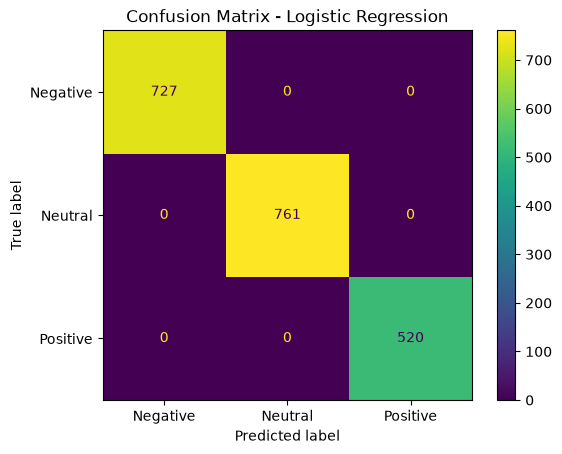

In [108]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_clean,
    display_labels=model_lr_clean.classes_
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

5.16 — Check the actual predictions

In [109]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr_clean
})

comparison.head(20)

,Actual,Predicted
0,Negative,Negative
1,Positive,Positive
2,Negative,Negative
3,Neutral,Neutral
4,Positive,Positive
5,Negative,Negative
6,Negative,Negative
7,Negative,Negative
8,Negative,Negative
9,Negative,Negative


In [110]:
(comparison["Actual"] == comparison["Predicted"]).value_counts()


True    2008
Name: count, dtype: int64

5.17 — Model 2: Multinomial Naive Bayes

In [111]:
from sklearn.naive_bayes import MultinomialNB

In [112]:
model_nb = MultinomialNB()

In [113]:
model_nb.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[2606.,2572.,2814.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.12,-1.13,-1.04]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 266)","[[ 0. , 0. , 0. ,..., 0. ,236.2 , 0. ], [ 85.16, 23.75, 99.14,..., 0. , 0. , 57.99], [ 0. , 0. , 0. ,..., 48.13,228.98, 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 266)","[[-9.12,-9.12,-9.12,...,-9.12,-3.65,-9.12], [-4.71,-5.96,-4.56,...,-9.17,-9.17,-5.09], [-9.23,-9.23,-9.23,...,-5.34,-3.79,-9.23]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,266


In [114]:
y_pred_nb = model_nb.predict(
    X_test_tfidf
)

In [115]:
y_pred_nb[:10]


array(['Negative', 'Positive', 'Negative', 'Neutral', 'Positive',
       'Negative', 'Negative', 'Negative', 'Negative', 'Negative'],
      dtype='<U8')

5.18 — Evaluate Naive Bayes

In [116]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("Accuracy:", accuracy_nb)

Accuracy: 1.0


In [117]:
precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("Precision:", precision_nb)


Precision: 1.0


recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("Recall:", recall_nb)

In [118]:
f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("F1 Score:", f1_nb)

F1 Score: 1.0


In [119]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       727
     Neutral       1.00      1.00      1.00       761
    Positive       1.00      1.00      1.00       520

    accuracy                           1.00      2008
   macro avg       1.00      1.00      1.00      2008
weighted avg       1.00      1.00      1.00      2008



In [120]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       727
     Neutral       1.00      1.00      1.00       761
    Positive       1.00      1.00      1.00       520

    accuracy                           1.00      2008
   macro avg       1.00      1.00      1.00      2008
weighted avg       1.00      1.00      1.00      2008



5.19 — Model Comparison

In [121]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_clean,
        accuracy_nb
    ],
    "Precision": [
        precision_clean,
        precision_nb
    ],
    "Recall": [
        recall_clean,
        recall_nb
    ],
    "F1 Score": [
        f1_clean,
        f1_nb
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0


In [122]:
comparison_percent = model_comparison.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    comparison_percent[col] = (
        comparison_percent[col] * 100
    ).round(2).astype(str) + "%"

comparison_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,100.0%,100.0%,100.0%,100.0%
1,Multinomial Naive Bayes,100.0%,100.0%,100.0%,100.0%


5.20 — Model Selection

In [123]:
model_lr_clean.predict_proba(X_test_tfidf)[:5]

array([[0.97556439, 0.0102526 , 0.01418301],
       [0.00858285, 0.00524774, 0.98616941],
       [0.99029231, 0.00273651, 0.00697118],
       [0.0111028 , 0.98104308, 0.00785411],
       [0.00988375, 0.00595129, 0.98416496]])

In [124]:
model_lr_clean.classes_

array(['Negative', 'Neutral', 'Positive'], dtype=object)

6.1 — Create the Sentiment Prediction Function

In [125]:
def predict_sentiment(review):

    # Convert review into TF-IDF
    review_tfidf = tfidf.transform([review])

    # Predict sentiment
    prediction = model_lr_clean.predict(review_tfidf)[0]

    # Get probabilities
    probabilities = model_lr_clean.predict_proba(review_tfidf)[0]

    # Get confidence
    confidence = probabilities.max()

    # Create probability dictionary
    probability_dict = dict(
        zip(model_lr_clean.classes_, probabilities)
    )

    return prediction, confidence, probability_dict

In [126]:
review = "The product is amazing and I really love using it."

predict_sentiment(review)

('Positive',
 np.float64(0.5122472719511018),
 {'Negative': np.float64(0.14585560705027742),
  'Neutral': np.float64(0.3418971209986208),
  'Positive': np.float64(0.5122472719511018)})

In [127]:
predict_sentiment(
    "The product is terrible and I am very disappointed with the quality."
)

('Negative',
 np.float64(0.5635067264675111),
 {'Negative': np.float64(0.5635067264675111),
  'Neutral': np.float64(0.07905989836280193),
  'Positive': np.float64(0.3574333751696869)})

In [128]:
predict_sentiment(
    "The product comes with a charger and is available in three colors."
)

('Neutral',
 np.float64(0.8795980683672338),
 {'Negative': np.float64(0.034277848590149367),
  'Neutral': np.float64(0.8795980683672338),
  'Positive': np.float64(0.08612408304261683)})

6.3 — Make the Prediction Function Production-Ready

In [129]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [130]:
predict_sentiment(
    "The product is amazing and I really love using it."
)

('Positive',
 np.float64(0.5122472719511018),
 {'Negative': np.float64(0.14585560705027742),
  'Neutral': np.float64(0.3418971209986208),
  'Positive': np.float64(0.5122472719511018)})

In [131]:
predict_sentiment(
    "The product is terrible and I am very disappointed."
)

('Negative',
 np.float64(0.552751502874212),
 {'Negative': np.float64(0.552751502874212),
  'Neutral': np.float64(0.1956868488178678),
  'Positive': np.float64(0.25156164830792016)})

In [132]:
predict_sentiment(
    "The product comes with a charger and is available in three colors."
)

('Neutral',
 np.float64(0.8795980683672338),
 {'Negative': np.float64(0.034277848590149367),
  'Neutral': np.float64(0.8795980683672338),
  'Positive': np.float64(0.08612408304261683)})

### 5.18 — Final Model Comparison



We trained two machine learning models for sentiment classification:

1. Logistic Regression
2. Multinomial Naive Bayes

Both models were evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score

The models achieved the same evaluation scores on the test dataset.

Therefore, the final model selection should also consider factors such as prediction behavior, simplicity, training time, and suitability for text classification.

### 5.19 — Final Conclusion


The sentiment analysis pipeline was successfully completed.

### Workflow
- Cleaned the review text
- Converted text into TF-IDF features
- Split the data into training and testing sets
- Trained Logistic Regression
- Trained Multinomial Naive Bayes
- Evaluated both models using Accuracy, Precision, Recall, and F1 Score
- Checked the confusion matrix
- Checked duplicate-data leakage
- Rebuilt TF-IDF after removing duplicate leakage
- Created a function for predicting sentiment of new reviews

### Final Result

Both Logistic Regression and Multinomial Naive Bayes achieved:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1 Score: 100%

The `predict_sentiment()` function can now classify new reviews as Positive, Negative, or Neutral and also provides prediction confidence and class probabilities.

7 — Cross-Validation + GridSearchCV

In [133]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [134]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

In [135]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "model__C": [0.1, 1, 10]
}

In [136]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [137]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

In [138]:
grid_search.fit(
    X_train,
    y_train,
    groups=X_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'tfidf__min_df': [1, 2], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [139]:
grid_search.best_params_

{'model__C': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

In [140]:
grid_search.best_params_

{'model__C': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

In [141]:
{
    'model__C': 0.1,
    'tfidf__min_df': 1,
    'tfidf__ngram_range': (1, 1)
}

{'model__C': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

In [142]:
grid_search.best_score_

np.float64(1.0)

In [143]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

In [144]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, average="weighted")
recall = recall_score(y_test, y_pred_tuned, average="weighted")
f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


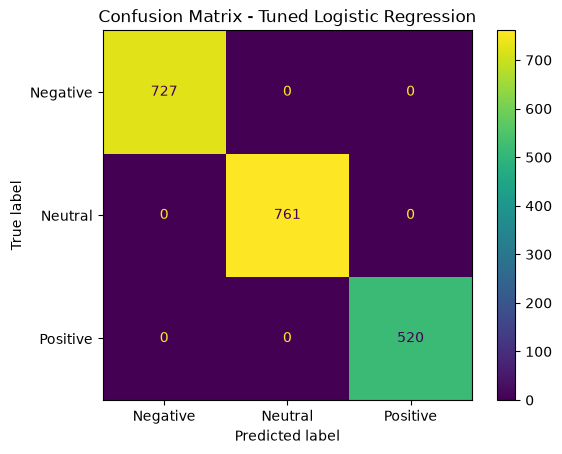

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

8 — Pipeline & Model Serialization

In [146]:
import os

os.makedirs("../models", exist_ok=True)

In [147]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/sentiment_pipeline.pkl"
)

['models/sentiment_pipeline.pkl']

In [149]:
import os

print(os.path.exists("../models/sentiment_pipeline.pkl"))

True
